/tmp/ipykernel_1215591/3313248012.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_yticklabels)


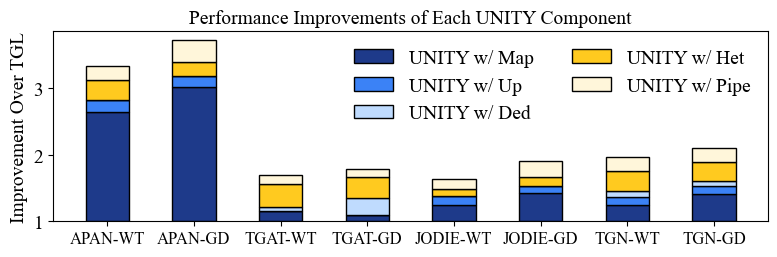

In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=14)
plt.rc('axes', titlesize=14)
# 从 ab.yaml 文件中加载数据
with open('ab.yaml', 'r') as file:
    data = yaml.safe_load(file)

# 数据类别
categories = ['Map', 'Up', 'Ded', 'Het', 'Pipe']
colors = ["#1E3A8A", "#3B82F6", "#BFDBFE", "#Ffca1f", "#FFF6da"]
# 创建空的堆叠数据
stacked_data = []

# 遍历模型和数据集组合，填充堆叠数据
for model in ['APAN', 'TGAT', 'JODIE', 'TGN']:
    for dataset in ['WIKITALK', 'GDELT']:
        # 提取对应模型和数据集的每个类别的数据
        row_data = [data[model][dataset].get(category, 0) for category in categories]
        stacked_data.append(row_data)

stacked_data = np.array(stacked_data)

# 创建堆叠柱状图
fig, ax = plt.subplots(figsize=(8, 2.8))

bar_width = 0.5  # 调宽柱子
index = np.arange(8)  # 8根柱子

# 为每个类别创建堆叠柱状图
bottom_values = np.zeros(8)
for i, category in enumerate(categories):
    ax.bar(index, stacked_data[:, i], bar_width, bottom=bottom_values, label=category, color=colors[i], edgecolor='black')  # 应用颜色
    bottom_values += stacked_data[:, i]

# 自定义图表
ax.set_ylabel('Improvement Over TGL')
ax.set_title('Performance Improvements of Each UNITY Component')
ax.set_xticks(index)
ax.set_xticklabels([
    'APAN-WT', 'APAN-GD', 'TGAT-WT', 'TGAT-GD',
    'JODIE-WT', 'JODIE-GD', 'TGN-WT', 'TGN-GD'
], fontsize = 12)

# 旋转 x 轴标签
plt.xticks()
current_yticks = ax.get_yticks()
new_yticklabels = [str(int(tick) + 1) for tick in current_yticks]
ax.set_yticklabels(new_yticklabels)
# 移动 legend 到右上角
ax.legend(ncol=2, loc='upper right', frameon=False, labels=['UNITY w/ Map', 'UNITY w/ Up', 'UNITY w/ Ded', 'UNITY w/ Het', 'UNITY w/ Pipe'])
plt.tight_layout()
plt.savefig('expab.pdf', bbox_inches='tight')
plt.show()
